In [1]:
import pandas as pd
from sklearn.datasets import make_classification
#https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html
#https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html

In [2]:
x,y = make_classification(n_samples=10000, n_features=30)

In [3]:
x.shape

(10000, 30)

In [4]:
pd.DataFrame(y)

,0
0,1
1,0
2,0
3,1
4,1
...,...
9995,1
9996,0
9997,1
9998,1


In [5]:
pd.DataFrame(x)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.417034,0.637715,1.164889,0.790832,-0.247540,0.581251,1.995326,0.153536,1.135566,-0.045722,...,-0.183785,-1.158887,1.975013,-0.134909,0.801524,0.820664,-2.085657,0.882335,0.652201,0.086629
1,-1.276622,1.888389,0.483280,1.499800,-0.681966,-0.671318,-0.899400,-0.882046,-0.934856,0.840722,...,1.155868,0.813803,1.055393,1.241514,1.007511,-0.297948,-1.038893,0.614075,-0.788935,1.850160
2,-1.207912,-0.484252,2.678625,-0.089967,0.923249,-0.605343,-1.207086,-0.953516,2.370118,0.782940,...,1.322304,1.111998,0.790308,0.664271,-0.759792,-0.314972,0.971430,-0.180486,-0.281068,0.217934
3,1.196986,-0.735049,-0.532026,-0.457720,-0.455066,0.896091,1.234586,0.941556,-1.887743,1.396640,...,-0.886015,2.117008,0.337329,-1.691769,-1.014962,-0.806048,0.229313,-1.543168,1.142234,0.108850
4,1.719732,1.568992,-0.708393,-0.082944,-0.506175,0.422651,-2.616439,0.437225,0.762839,0.049957,...,-1.186108,-0.828405,-1.410547,-1.305671,1.318506,0.646632,0.572233,-0.879722,1.817842,-1.005995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.392813,-1.899638,0.176789,0.339523,1.312326,-0.576802,0.103422,-0.613104,-0.744076,-0.932778,...,-0.399791,-0.130924,0.543748,1.010926,-0.937331,0.913773,0.837316,0.728147,0.152921,-0.250216
9996,1.370609,1.959217,-0.357260,-0.408331,0.828179,-0.012011,0.587221,-0.327521,-0.093788,-0.105688,...,-1.502805,0.327076,0.136131,1.298777,0.144814,-0.074028,-1.257734,-1.691967,0.314049,-0.374609
9997,-0.256807,0.433826,0.917503,0.086856,0.524729,-1.338167,0.821264,0.491957,-1.704354,0.444028,...,1.358605,-0.146457,1.685691,-0.581545,-1.242974,0.303695,-0.581571,-1.376384,2.133420,-0.313254
9998,2.471131,1.270804,-0.345195,0.943857,-0.677327,-1.872724,0.545019,0.368774,-0.816354,0.478807,...,-2.572358,1.139275,0.116435,2.297277,0.985582,0.179765,-1.165911,0.685582,0.845307,0.197049


In [6]:
from sklearn.model_selection import train_test_split as tts

In [7]:
xtrain,xtest,ytrain,ytest = tts(x,y,test_size=3000, random_state=42)

In [8]:
xtest.shape

(3000, 30)

In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
train_score = []
test_score = []

In [11]:
max_depth = [n for n in range(1,30)]

In [12]:
max_depth

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29]

In [13]:
for depth in max_depth:
    clf = DecisionTreeClassifier(max_depth=depth)
    clf.fit(xtrain,ytrain)
    
    #training accuracy
    train_acc = clf.score(xtrain,ytrain)
    train_score.append(train_acc)
    
    #test accuracy
    test_acc = clf.score(xtest,ytest)
    test_score.append(test_acc)
    
    print('Max depth = %d, training_accuracy = %f, test_accuracy = %f'%(depth,train_acc,test_acc))

Max depth = 1, training_accuracy = 0.915857, test_accuracy = 0.906000
Max depth = 2, training_accuracy = 0.925286, test_accuracy = 0.915667
Max depth = 3, training_accuracy = 0.925857, test_accuracy = 0.915000
Max depth = 4, training_accuracy = 0.973000, test_accuracy = 0.958667
Max depth = 5, training_accuracy = 0.977571, test_accuracy = 0.964333
Max depth = 6, training_accuracy = 0.982429, test_accuracy = 0.961667
Max depth = 7, training_accuracy = 0.985857, test_accuracy = 0.959000
Max depth = 8, training_accuracy = 0.991000, test_accuracy = 0.956333
Max depth = 9, training_accuracy = 0.993857, test_accuracy = 0.956000
Max depth = 10, training_accuracy = 0.995714, test_accuracy = 0.955000
Max depth = 11, training_accuracy = 0.996571, test_accuracy = 0.955667
Max depth = 12, training_accuracy = 0.997429, test_accuracy = 0.954000
Max depth = 13, training_accuracy = 0.997714, test_accuracy = 0.953667
Max depth = 14, training_accuracy = 0.998286, test_accuracy = 0.954333
Max depth = 15,

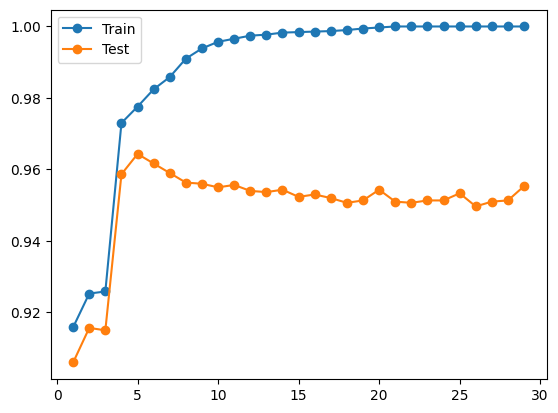

In [14]:
from matplotlib import pyplot as plt
plt.plot(max_depth, train_score, '-o', label = 'Train')
plt.plot(max_depth, test_score, '-o', label= 'Test')
plt.legend()